In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<Axes: xlabel='0'>

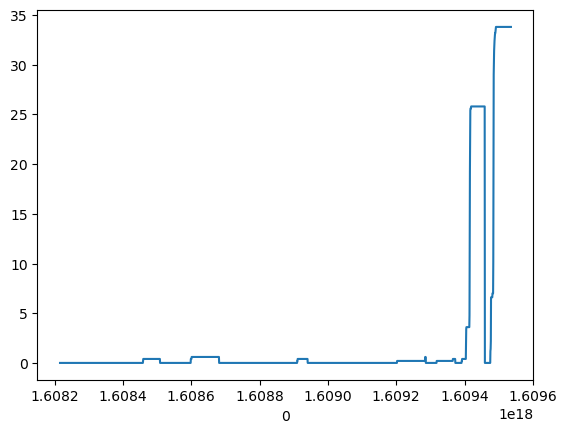

In [2]:
df=pd.read_csv("subset_stabil_banten_rr.csv",header=None)
df.index=df[0]
df.drop(0,axis=1)
df[1].plot()

In [7]:
torch.tensor(2.123).cosh()

<function Tensor.cosh>

In [8]:
#df=pd.read_csv("DailyDelhiClimateTrain.csv")
#df['date']=df['date'].apply(pd.to_datetime).astype(np.int64)
#data=torch.tensor(df.values[:,:2]).to(torch.float32)
def sech(x):
    return 1/x.cosh()
N=200
data=torch.empty(N, 2)
#data[:,0]=data[:,0]/data[:,0].diff().mean()
#data[:,1]=(data[:,1]-data[:,1].mean())/data[:,1].std()#data[:,1].log1p()#
data[:,0]=torch.linspace(-100,100, N)
data[:,1]=(
    (data[:,0]*0.001).sin()
    #+(data[:,0]*0.01+1).sin()*.5
    +(data[:,0]*0.1+10).sin()*.1
    #+(data[:,0]+100).sin()*.01
)*(1-sech(data[:,0]/50))
data[:,1]=(data[:,1]-data[:,1].mean())/data[:,1].std()
assert ~(data.isnan().any())

In [21]:
raw=[0,0,0,0,0,0,8,10.8,11.4,11.4,11.4,11.4,11.4,11.4,11.4,11.4,11.4,11.4,11.4,11.4]
len_raw=len(raw)
data=torch.empty(len_raw,2)
data[:,0]=torch.linspace(0,len_raw, len_raw)
data[:,1]=torch.tensor(raw)

<Axes: >

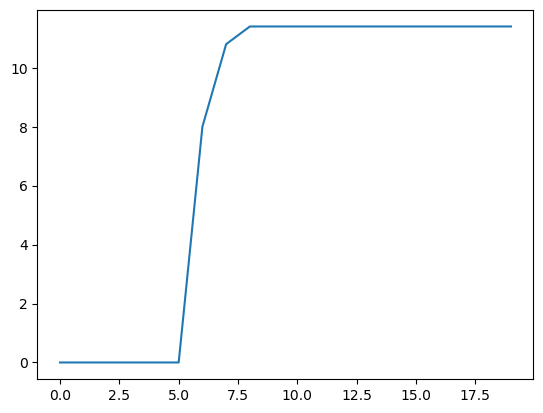

In [22]:
pd.Series(data[:,1]).plot()

In [23]:
def find_closest_left_right(K: torch.Tensor, Q: torch.Tensor) -> torch.Tensor:
    """
    For each value in Q, find indices (in the original unsorted K)
    of the closest left and right neighbors from K.

    Args:
        K (torch.Tensor): 1D float tensor of shape (N,). Unsorted.
        Q (torch.Tensor): 1D float tensor of shape (M,).

    Returns:
        torch.Tensor: Long tensor of shape (M, 2), where each row contains 
                      [left_idx, right_idx] such that K[left_idx] <= Q[i] < K[right_idx],
                      using original indices of unsorted K, with clamping at boundaries.
    """
    # Sort K and track original indices
    sorted_K, sort_idx = K.sort()
    # sort_idx maps sorted_K → K
    inv_sort_idx = sort_idx

    # Use searchsorted on sorted_K
    right_pos = torch.searchsorted(sorted_K, Q, right=True)
    left_pos = right_pos - 1

    # Clamp to valid index range
    left_pos = torch.clamp(left_pos, min=0)
    right_pos = torch.clamp(right_pos, max=K.size(0) - 1)

    # Map sorted positions back to original K indices
    left_idx = inv_sort_idx[left_pos]
    right_idx = inv_sort_idx[right_pos]

    return torch.stack((left_idx, right_idx), dim=1).long()

In [24]:
import torch
def smush(x):
    #like tanh(x) except range is (-inf, inf)
    return x.abs().log1p()*x.sign()
def msech1p(x):
    #similar to 1-sech(x)
    x2=x.pow(2)
    return x2/(1+x2)
H1=32
H2=32
class EncLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.v_encoder = nn.Sequential(
            nn.Linear(H1,H2),
            nn.LeakyReLU(),
            nn.Linear(H2,H1)
        )
        self.k_encoder = nn.Sequential(
            nn.Linear(1,H2),
            nn.LeakyReLU(),
            nn.Linear(H2,H1),
            nn.LeakyReLU(),
        )
        self.recoder = nn.Sequential(
            nn.Linear(H1,H2),
            nn.LeakyReLU(),
            nn.Linear(H2,H1),
            nn.LeakyReLU(),
        )
        self.recoder2 = nn.Sequential(
            nn.Linear(H1,H2),
            nn.LeakyReLU(),
            nn.Linear(H2,H1),
            nn.LeakyReLU(),
        )
        self.e_dk_norm = nn.LayerNorm(H1)
        self.e_v_norm = nn.LayerNorm(H1)
        self.a_e = nn.Parameter(torch.tensor(0.8))
        self.a_v = nn.Parameter(torch.tensor(0.8))
    def forward(self,k,v,e):
        ku = k.mean()
        dk = smush(k-ku)
        e_dk = self.k_encoder(dk)
        e_dk = self.e_dk_norm(e_dk)
        e_v = self.v_encoder(v)
        e_v=self.e_v_norm(e_v)
        e=e+self.a_e*self.recoder((e_dk*e_v).sum(-2))
        v=v+self.a_v*e_v*self.recoder2(e)
        return e,v
class Encoder(nn.Module):
    def __init__(self, n_layers = 3):
        super().__init__()
        self.layers = nn.ModuleList([
            EncLayer() for _ in range(n_layers)
        ])
        self.e_norm=nn.LayerNorm(H1)
        self.v_norm=nn.LayerNorm(H1)
    def forward(self, k, v):
        e=0
        for layer in self.layers:
            e,v=layer(k,v,e)
            e=self.e_norm(e)
            v=self.v_norm(v)
        return e,v
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(H1,H2),
            nn.LeakyReLU(),
            nn.Linear(H2,1),
        )
        self.k_encoder = nn.Sequential(
            nn.Linear(1,H2),
            nn.LeakyReLU(),
            nn.Linear(H2,H1),
            nn.LeakyReLU(),
        )
        self.dk_e_norm = nn.LayerNorm(H1)
    def forward(self, k, v, latent_v, q, interp=False):
        #k: (N, 1)
        #v: (N, 1)
        #latent_v: (N, H)
        #q: (M, 1)
        kf = k.flatten()
        vf = v.flatten()
        qf = q.flatten()
        assert max(k.shape), len(kf)
        assert max(q.shape), len(qf)
        lr = find_closest_left_right(kf,qf)
        dk=smush(kf.view(-1)[lr]-qf.view(-1,1))
        assert dk.shape[1]==2
        dk_encoded = self.k_encoder(dk.unsqueeze(-1))
        dk_encoded = self.dk_e_norm(dk_encoded)#(dk_encoded-dk_encoded.mean())/dk_encoded.std()
        # print("dk_encoded.std:",dk_encoded.std())
        # print("latent_v.std:",latent_v.std())
        # print("latent_v[lr].std:",latent_v[lr].std())
        encoded = dk_encoded*latent_v[lr]
        # print("encoded.std:",encoded.std())
        decoded_offset = self.decoder(encoded).view(-1,2)#(N,2,1)
        decoded = vf[lr]+decoded_offset*msech1p(dk)*int(not interp)#*v.std()/(k.max()-k.min()+1)
        assert decoded.shape==dk.shape
        # print("dk:",dk)
        abs_offset = dk.abs().pow(2)
        closeness = 1.0 / (abs_offset + 1e-8)
        lerp_weight = closeness / closeness.sum(dim=-1, keepdim=True)
        #lerp_weight = 1-dk.abs()/(dk.diff()+1e-9)
        # print("lerp_weight=",lerp_weight)
        # print("lerp_weight.var:",lerp_weight.var())
        weighted = (lerp_weight*decoded).sum(-1).unsqueeze(-1)
        assert weighted.shape==q.shape, f"weighted:{weighted.shape}, q:{q.shape}, "
        return weighted
class Interpolator(nn.Module):
    def __init__(self, n_layers = 3):
        super().__init__()
        self.ienc= nn.Sequential(
            nn.Linear(1,H2),
            nn.LeakyReLU(),
            nn.Linear(H2,H1)
        )
        self.enc = Encoder(n_layers=n_layers)
        self.dec = Decoder()
    def forward(self, k,v,q, interp=False):
        ev = self.ienc(v)
        e,latent_v = self.enc(k,ev)
        y = self.dec(k,v,latent_v,q,interp=interp)
        return y

In [44]:
model=Interpolator()
optim=torch.optim.AdamW(model.parameters(),lr=0.001)

In [50]:
mask.float().mean()

tensor(0.5556)

In [45]:
from tqdm import tqdm
FIELD=9#25
IN=3#4
#iterator = tqdm(total=len(range(0,data.shape[0]-FIELD,FIELD)))
total_loss=0
TIMER=10
for epoch in range(500):
    #iterator.refresh()
    #iterator.reset()
    out=data.clone()
    interp=data.clone()
    interp[:,0]=0
    out[:,0]=0
    for start in range(epoch%FIELD,data.shape[0]-FIELD,FIELD):
        #iterator.update()
        end = start+FIELD
        mask = torch.zeros(FIELD,dtype=bool)
        mask[0] = True
        mask[-1] = True
        ranger = torch.arange(start, end)
        indices = torch.rand(FIELD).topk(IN).indices
        mask[indices] = True
        xrange = ranger[mask]
        yrange = ranger[~mask]
        k = data[xrange,0].view(-1,1)
        v = data[xrange,1].view(-1,1)
        q = data[yrange,0].view(-1,1)
        y = data[yrange,1].view(-1,1)
        pred = model(k,v,q,interp=False)
        with torch.no_grad():
            interpolation = model(k,v,q,interp=True)
        out[yrange,1]=pred.flatten().detach()
        out[yrange,0]=1
        interp[yrange,1]=interpolation.flatten().detach()
        interp[yrange,0]=1
        loss = (pred-y).abs().pow(1).sum()
        loss0 = (interpolation-y).abs().pow(1).sum()
        total_loss = total_loss+loss-loss0#(loss-loss0).relu()
    #if total_loss<-0.05:
    #    break
    if epoch>0 and epoch%TIMER==0:
        total_loss=total_loss/TIMER
        model.zero_grad(set_to_none=True)
        total_loss.backward()
        optim.step()
        print(f"{epoch+1:03d}",f"total_loss:{total_loss.item():.2f}")
        total_loss=0
    #iterator.set_description(f"loss:{total_loss.item():.2f}")

011 total_loss:0.07
021 total_loss:0.03
031 total_loss:0.05
041 total_loss:0.06
051 total_loss:0.06
061 total_loss:0.04
071 total_loss:0.04
081 total_loss:0.02
091 total_loss:0.05
101 total_loss:0.06
111 total_loss:0.01
121 total_loss:0.00
131 total_loss:0.02
141 total_loss:-0.00
151 total_loss:0.03
161 total_loss:0.02
171 total_loss:0.01
181 total_loss:0.03
191 total_loss:-0.01
201 total_loss:0.01
211 total_loss:-0.01
221 total_loss:-0.04
231 total_loss:-0.00
241 total_loss:0.01
251 total_loss:-0.03
261 total_loss:-0.01
271 total_loss:-0.04
281 total_loss:-0.02
291 total_loss:-0.05
301 total_loss:-0.09
311 total_loss:-0.00
321 total_loss:0.03
331 total_loss:-0.00
341 total_loss:-0.01
351 total_loss:0.00
361 total_loss:-0.10
371 total_loss:-0.01
381 total_loss:0.07
391 total_loss:-0.08
401 total_loss:-0.18
411 total_loss:-0.09
421 total_loss:-0.07
431 total_loss:0.00
441 total_loss:-0.11
451 total_loss:0.01
461 total_loss:-0.15
471 total_loss:-0.12
481 total_loss:-0.08
491 total_loss:-

In [46]:
N_EVALS=100
eval_loss=0
eval_loss0=0
counter=0
with torch.no_grad():
    for epoch in range(N_EVALS):
        for start in range(epoch%FIELD,data.shape[0]-FIELD,FIELD):
            #iterator.update()
            end = start+FIELD
            mask = torch.zeros(FIELD,dtype=bool)
            mask[0] = True
            mask[-1] = True
            ranger = torch.arange(start, end)
            indices = torch.rand(FIELD).topk(IN).indices
            mask[indices] = True
            xrange = ranger[mask]
            yrange = ranger[~mask]
            k = data[xrange,0].view(-1,1)
            v = data[xrange,1].view(-1,1)
            q = data[yrange,0].view(-1,1)
            y = data[yrange,1].view(-1,1)
            pred = model(k,v,q,interp=False)
            interpolation = model(k,v,q,interp=True)
            out[yrange,1]=pred.flatten().detach()
            out[yrange,0]=1
            interp[yrange,1]=interpolation.flatten().detach()
            interp[yrange,0]=1
            loss = (pred-y).abs().pow(1).mean()
            loss0 = (interpolation-y).abs().pow(1).mean()
            eval_loss=eval_loss+loss
            eval_loss0=eval_loss0+loss0
            counter+=1
eval_loss=eval_loss/counter
eval_loss0=eval_loss0/counter

In [47]:
eval_loss

tensor(1.0163)

In [48]:
eval_loss0

tensor(1.0309)

In [18]:
torch.save(model.state_dict(),"model.pth")

In [27]:
combined=pd.DataFrame({
    "y":data[:,1].numpy(),
    "p":(out[:,1]).numpy(),
    "i":(interp[:,1]).numpy(),
    "dp":(out[:,1]-data[:,1]).numpy(),
    "di":(interp[:,1]-data[:,1]).numpy(),
    "x":data[:,0].numpy(),
})
combined.index=data[:,0].numpy()

In [28]:
loss0,loss

(tensor(9.5367e-07), tensor(0.0083, grad_fn=<SumBackward0>))

In [29]:
(combined['dp']).abs().pow(1).sum()-(combined['di']).abs().pow(1).sum()

0.008256912

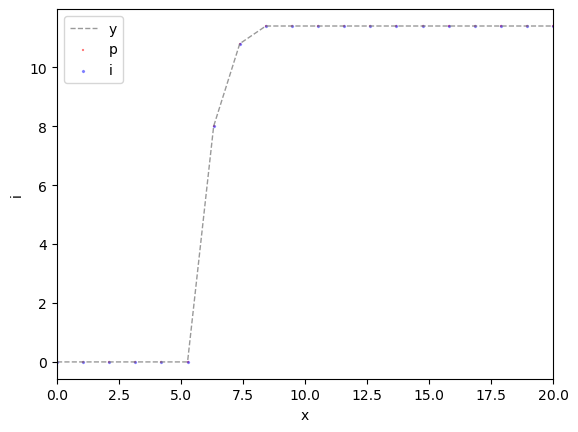

In [30]:
tmp=combined.iloc[:]['y']
plt.xlim((tmp.index.min(),tmp.index.max()))
tmp.plot(linewidth=1,c='grey',linestyle='--',alpha=0.8)
combined.plot.scatter(x="x",y="p",c='r',marker='+',s=2,alpha=0.5,label="p",ax=plt.gca())
combined.plot.scatter(x="x",y="i",c='b',marker='x',s=2,alpha=0.5,label="i",ax=plt.gca())
#tmp=(combined.loc[(out[:,0]==1).numpy(),'p'])
#plt.scatter(tmp.index,tmp.values,s=5,c='r',marker='+',alpha=0.5)
#tmp=(combined.loc[(interp[:,0]==1).numpy(),'i'])
#plt.scatter(tmp.index,tmp.values,s=5,c='b',marker='+',alpha=0.5)
# combined['p']\
#     .plot(c='r',linewidth=1,alpha=0.5)
# combined['i']\
#     .plot(c='b',linewidth=1,alpha=0.5)
# tmp=(combined['p'])
# plt.scatter(tmp.index,tmp.values,s=5,c='r',marker='+',alpha=0.5)

plt.legend()
plt.savefig("test.svg")

<Axes: xlabel='x', ylabel='di'>

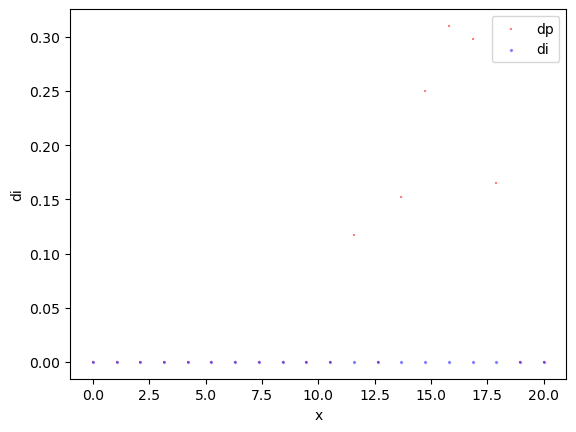

In [53]:
combined.plot.scatter(x="x",y="dp",c='r',marker='+',s=2,alpha=0.5,label="dp",ax=plt.gca())
combined.plot.scatter(x="x",y="di",c='b',marker='x',s=2,alpha=0.5,label="di",ax=plt.gca())


In [9]:
combined

,x,y,p
x,,,
2680331.75,2680331.75,-0.297828,-0.297828
2680332.75,2680332.75,-0.297828,-0.297828
2680333.75,2680333.75,-0.297828,-0.297828
2680334.75,2680334.75,-0.297828,-0.297828
2680335.75,2680335.75,-0.297828,-0.303248
...,...,...,...
2682526.75,2682526.75,4.034262,4.034262
2682527.75,2682527.75,4.034262,4.034262
2682528.75,2682528.75,4.034262,4.034262


In [117]:
y

tensor([[-0.2978],
        [-0.2978],
        [-0.2978],
        [-0.2978],
        [-0.2978]])